### 2547203 MACHINE LEARNING LAB 7

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
print("Number of samples:", iris.data.shape[0])
print("Number of features:", iris.data.shape[1])
print("\nFeature Names:")
print(iris.feature_names)
print("\nTarget Classes:")
print(iris.target_names)
print("\nFirst Five Records:")
print(df.head())
print("\nClass Distribution:")
print(df["target"].value_counts())


Number of samples: 150
Number of features: 4

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

First Five Records:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



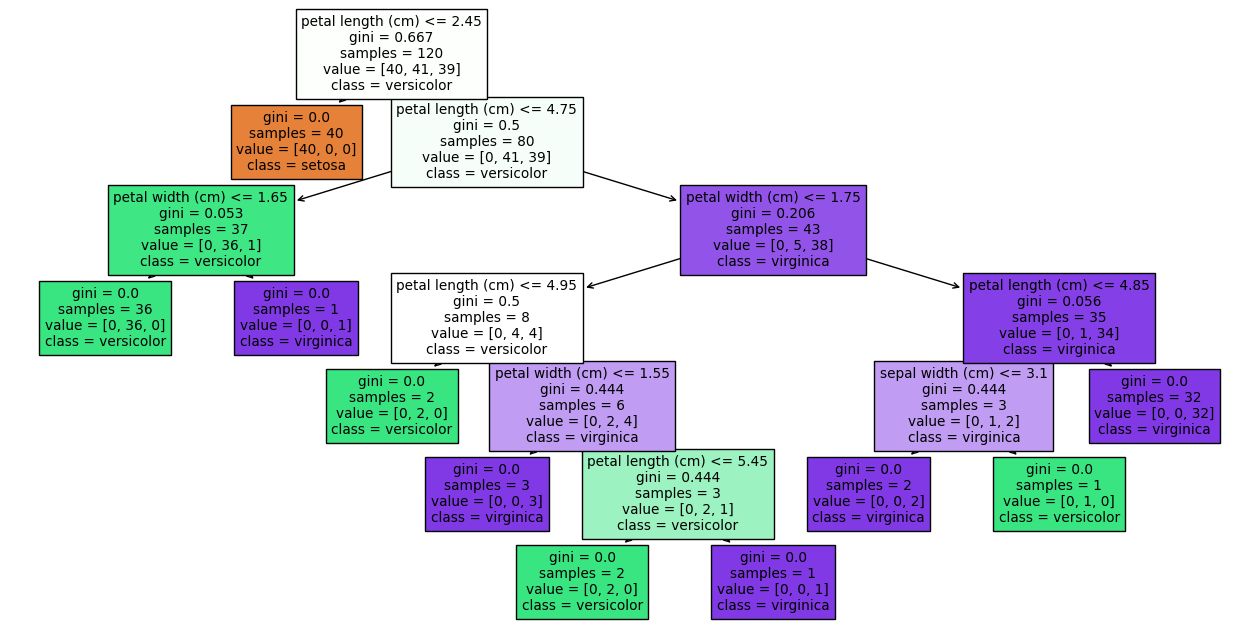

Depth: 6
Leaf Nodes: 10


In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

print("Depth:", dt.get_depth())
print("Leaf Nodes:", dt.get_n_leaves())

In [5]:
criteria=["gini","entropy"]

for c in criteria:
    model=DecisionTreeClassifier(
        criterion=c,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    print("\nCriterion:",c)
    print("Accuracy:",accuracy_score(y_test,pred))
    print("Depth:",model.get_depth())
    print("Leaves:",model.get_n_leaves())
    print("Root Feature:",iris.feature_names[model.tree_.feature[0]])


Criterion: gini
Accuracy: 1.0
Depth: 6
Leaves: 10
Root Feature: petal length (cm)

Criterion: entropy
Accuracy: 1.0
Depth: 6
Leaves: 10
Root Feature: petal length (cm)


In [6]:
depths=[1,2,3,4,None]

for d in depths:

    model=DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train,y_train)

    train_acc=model.score(X_train,y_train)
    test_acc=model.score(X_test,y_test)

    print(d,
          train_acc,
          test_acc,
          model.get_depth())

1 0.675 0.6333333333333333 1
2 0.95 0.9666666666666667 2
3 0.9583333333333334 1.0 3
4 0.975 1.0 4
None 1.0 1.0 6


In [7]:
splits=[2,5,10,20]

for s in splits:

    model=DecisionTreeClassifier(
        min_samples_split=s,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    print(
        s,
        accuracy_score(y_test,pred),
        model.get_depth(),
        model.get_n_leaves()
    )

2 1.0 6 10
5 1.0 5 8
10 1.0 4 6
20 1.0 4 6


In [8]:
leaf=[1,2,5,10]

for l in leaf:

    model=DecisionTreeClassifier(
        min_samples_leaf=l,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    print(
        l,
        accuracy_score(y_test,pred),
        model.get_depth(),
        model.get_n_leaves()
    )

1 1.0 6 10
2 1.0 5 8
5 1.0 4 6
10 0.9666666666666667 4 6


In [9]:
from sklearn.model_selection import GridSearchCV

params={
    "criterion":["gini","entropy"],
    "max_depth":[2,3,4,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

grid=GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

best=grid.best_estimator_

pred=best.predict(X_test)

print("Test Accuracy:",accuracy_score(y_test,pred))

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score: 0.9583333333333334
Test Accuracy: 1.0


# Task 10: Analysis

### 1. What is the role of the `criterion` parameter in a Decision Tree?

The **criterion** parameter determines how the Decision Tree selects the best feature to split the data at each node. It measures the impurity of the dataset and chooses the split that results in the purest child nodes.

- **Gini Index (`criterion='gini'`)**: Measures impurity based on the probability of incorrect classification. It is computationally faster and is the default criterion in Scikit-learn.
- **Entropy (`criterion='entropy'`)**: Uses Information Gain to measure impurity. It generally requires more computation but may produce a similar tree.

Both criteria aim to create splits that separate the classes as effectively as possible.

---

### 2. How does `max_depth` influence underfitting and overfitting?

The `max_depth` parameter controls the maximum number of levels in the Decision Tree.

- **Small `max_depth` (e.g., 1 or 2):**
  - Produces a simple tree.
  - May not capture enough patterns in the data.
  - Results in **underfitting**, leading to lower accuracy.

- **Moderate `max_depth` (e.g., 3 or 4):**
  - Balances model complexity and generalization.
  - Usually provides the best testing performance.

- **Large `max_depth` or `None`:**
  - Allows the tree to grow until all leaves are pure.
  - May memorize the training data.
  - Results in **overfitting**, where training accuracy is very high but testing performance may decrease.

---

### 3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?

Increasing these parameters restricts the growth of the Decision Tree.

- **Larger `min_samples_split`:**
  - Requires more samples before a node can be split.
  - Reduces the total number of splits.
  - Produces a shallower tree.

- **Larger `min_samples_leaf`:**
  - Ensures each leaf contains a minimum number of samples.
  - Prevents the creation of very small leaf nodes.
  - Reduces model complexity and helps improve generalization.

As these values increase, the tree becomes simpler and less likely to overfit.

---

### 4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.

Among all the hyperparameters, **`max_depth`** had the greatest impact on the model's performance.

**Observations:**

- Changing `max_depth` significantly affected both training and testing accuracy.
- Very small depths resulted in underfitting.
- Very large depths increased the risk of overfitting.
- Moderate values (typically 3 or 4 for the Iris dataset) achieved the best balance between accuracy and generalization.

In comparison, changing `min_samples_split` and `min_samples_leaf` mainly reduced tree complexity, while the choice of `criterion` (Gini or Entropy) usually had only a minor effect on accuracy.

---

### 5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.

The most suitable model is the **Decision Tree obtained after hyperparameter tuning using GridSearchCV**.

**Justification:**

- It achieved the highest cross-validation score.
- It provided excellent testing accuracy.
- It balanced model complexity and predictive performance.
- It reduced the chances of both underfitting and overfitting.
- The optimized parameters produced a tree that generalized well to unseen data.

If hyperparameter tuning is not used, a Decision Tree with **`max_depth = 3` or `max_depth = 4`** is generally recommended for the Iris dataset because it provides high accuracy while maintaining a relatively simple and interpretable tree.
